<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_15_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch: Autoencoder convolucional Fashion-MNIST

## Refs.

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb

## **Ejercicio 1)** Importando librerías

**0)** De ser necesario, **instale PyTorch** escribiendo

    !pip3 install torch torchvision torchaudio torchviz

**1)** Importe las librerías estandard de Python: `os`, `datetime`, `collections` y `pickle`.

**2)** Importe las siguientes librerías third party de Python: `matplotlib.pyplot`, `numpy`, `scipy`, `sklearn`, `pandas`, `dill` y `json`.

**3)** Importe las librerias necesarias de **PyTorch**: `torch` y `torchvision`.

**4)** Importe la librería: `google.colab`.

In [ ]:
# 1.0)
!pip3 install torch torchvision torchaudio torchviz

In [ ]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [ ]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json

In [ ]:
# 1.3)
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

In [ ]:
# 1.4)
import google.colab
from google.colab import files

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

In [ ]:
# 2.1)
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])

# Download and load the training data
train_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set_orig = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

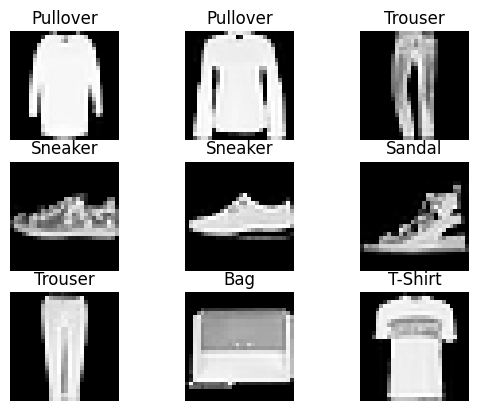

In [ ]:
# 2.2)
labels_names = {
    0: "T-Shirt",    # Remera manga corta
    1: "Trouser",    # Pantalon
    2: "Pullover",   # Buzo
    3: "Dress",      # Vestido
    4: "Coat",       # Abrigo
    5: "Sandal",     # Sandalia
    6: "Shirt",      # Remera manga larga
    7: "Sneaker",    # Zapatilla
    8: "Bag",        # Bolso
    9: "Ankle Boot", # Bota
}

figure = plt.figure()
cols,rows = 3,3
for i in range(1,cols*rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # Los números aleatorios tambien se pueden generar desde pytorch. Util para trabajar en la GPU.
    # eligiendo el j así estamos viendo 9 imagenes al azar del conjunto, o sea, pueden repetirse el tipo
    image,label = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    plt.title(labels_names[label])
    plt.axis("off")
    plt.imshow(image.squeeze(),cmap="Greys_r")
plt.show()

## Ejercicio 3) Creando un `DataSet` personalizado.

**1)** Con el fin de implementar un autoencoder, cree una clase derivada de la clase `DataSet` (llámela, por ejemplo `CustomDataset`) que, en vez de retornal el label asociado a cada imagen de `FashionMNIST`, retorne la imagen misma.

**2)** Utilice dicha clase para transformar los conjuntos de entrenamiento y testeo de `FashionMNIST` pensados para clasificación, a correspondientes conjuntos pensados para entrenar un autoencoder.
Para ello, defina una clase `CustomDataset` que deriva de la clase `Dataset`, cuyo método `__getitem__(self,i)` retorne el pair `input,output` donde tanto `input` cómo `output` son iguales a la $i$-ésima imagen del dataset.

In [ ]:
# 3.1)
# Creamos una subclase de Dataset que nos sirva para muestrear imagenes en el entrenamiento del autoencoder
class CustomDataset(Dataset):
    def __init__(self,dataset):
        self.dataset=dataset
    # Redefinimos el método .__len__()
    def __len__(self):
        return len(self.dataset)
    # Redefinimos el método .__getitem__()
    def __getitem__(self,i):
        image,label=self.dataset[i]
        input  = image
        #output = torch.flatten(image) # Reescribimos el label original con una version achatada de la imagen.
        output = image
        return input,output

In [ ]:
# 3.2)
# Convertimos FashionMNIST Dataset a CustomDataset
train_set = CustomDataset(train_set_orig)
valid_set = CustomDataset(valid_set_orig)

## Ejercicio 4) Red Neuronal Autoencoder

**1)** Defina y cree una red neuronal autoenconder convolucional.
El **encoder** deberá estar constituido por las siguientes capas:

Primero una capa convolucional 2D constituida por:

* Una capa `Conv2d` (ver https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) que deberá mapear $1$ canal de entradas de dimensiones $28\times 28$ a $16$ canales de de salida de dimensiones $(26,26)$. Para ello utilice un kernel de dimensiones $(3,3)$ y el resto de los parámetros en sus valores por defecto.
* Una capa `ReLU`.
* Una capa `Dropout`.
* Una capa `MaxPool` (ver https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) con un kernel de dimensiones $(2,2)$, de manera que mapeará entradas de dimensiones $(26,26)$ a salidas de dimensiones $(13,13)$.

Luego una capa lineal constituida por:

* Una capa `Flatten` que mapea una entrada de $16$ canales de dimensiones $(13,13)$ a un vector de dimensión $16\times 13\times 13$.
* Una capa `Linear` que mapea un vector de dimensión $16\times 13\times 13$ a un vector de dimensión $n$.
* Una capa `ReLU`.
* Una capa `Dropout`.

El **decoder** deberá estar constituido por las siguientes capas:

Primero una capa lineal constituida por:

* Una capa `Linear` que mapea un vector de dimensión $n$ a un vector de dimensión $16\times 13\times 13$.
* Una capa `ReLU`.
* Una capa `Dropout`.
* Una capa `Unflatten` que mapea un vector de entrada de dimensión $16\times 13\times 13$ a $16$ canales de dimensiones $(13,13)$.

Luego una capa convolucional 2D transpuesta, constituida por:

* una capa `ConvTranspose2d` (ver https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) que mapea $16$ canales de dimensiones $(13,13)$ a $1$ canal de dimensiones $(28,28)$. Para ello, utilice un kernel de dimensiones $(4,4)$ y un stride de dimensiones $(2,2)$, dejando el resto de los parámetros en sus valores por defecto.
* Una capa `Sigmoid`.
* Una capa `Dropout`.

**2)** Grafique, comparativamente, las imagenes a predecir vs las imagenes predichas por el modelo sin entrenar usando $n=64$ y dropout $p=0.2$.

In [ ]:
# 4.1)
class AutoEncoderConv(nn.Module):
    def __init__(self,n,p=0.2): #  inicializa los atributos del objeto que creamos
        super(AutoEncoderConv, self).__init__()

        self.flatten = nn.Flatten() # "capa" flatten, achata el array

        # defino el encoder como secuencia
        self.encoder = nn.Sequential(
            # capa conv2d
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=0), # de 1 canal a 16, con kernel (3, 3). (1, 28, 28)==>(16, 26, 26). Se pierden 2 por la primera y ultima fila y primera y ultima columna.
            nn.ReLU(),
            nn.Dropout(p),
            nn.MaxPool2d(2, 2), # a cada canal lo reduce a la mitad. (16, 26, 26)==>(16, 13, 13)
            # capa lineal
            nn.Flatten(), # un vector de 16*13*13
            nn.Linear(16*13*13,n), # mapea un vector de 16*13*13 con uno de n (de la capa del medio)
            nn.ReLU(),
            nn.Dropout(p),
        )

        self.decoder = nn.Sequential(
            # capa lineal
            nn.Linear(n,16*13*13),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Unflatten(1, (16, 13, 13)), # de 1 a 16 de 13x13
            # capa conv2d
            nn.ConvTranspose2d(16, 1, kernel_size=(4,4), stride=2), # (16, 13, 13) => (1, 28, 28). Es lo opuesto de conv2d y maxpool juntos, el kernel se mueve de a 2 (stride)
            nn.Sigmoid(),
            nn.Dropout(p),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
# 4.2)
n = 64
model = AutoEncoderConv(n) # uso 64 neuronas en la capa intermedia

In [ ]:
def batch(x):
  return x.unsqueeze(0) # (28,28)=>(1,28,28)

def unbatch(x):
  return x.squeeze().detach().cpu().numpy() # (1, 28, 28)=>(28, 28)

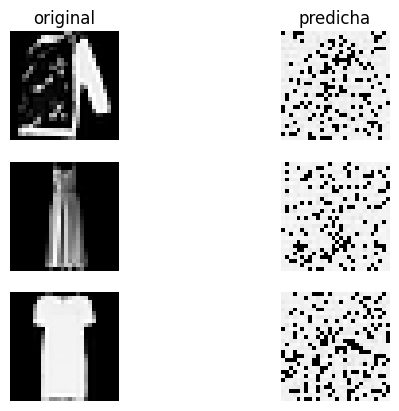

In [ ]:
# Miramos que imagenes predice el modelo sin entrenar
figure = plt.figure()
rows,cols = 3,2
i = 0 # subplot index
for row in range(1,rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # elegimos un elemento random de el conjunto de entrenamiento
    # Ploteamos la imagen original
    i += 1
    image,flatten_imagen = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    if row==1: # le ponemos titulo solo a la primera imagen
      plt.title("original")
    plt.axis("off")
    plt.imshow(unbatch(image),cmap="Greys_r") # plotemaos la original
    # Ploteamos la imagen predicha
    i += 1
    figure.add_subplot(rows,cols,i)
    if row==1:
      plt.title("predicha")
    plt.axis("off")
    image_pred = unbatch(model(batch(image)))
    plt.imshow(image_pred,cmap="Greys_r")
plt.show()

## Ejercicio 5) Entrenando el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de prueba o validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` que estén definidos sobre  el `train_set` (conjunto de entranmiento) y el `valid_set` (conjunto de prueba) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando el **Error Cuadrático Medio**.

**5)** Cree un optimizador con un learning rate igual a $10^{-3}$.
Pruebe con **ADAM**.

**6)** Cree una instancia del modelo con $n=64$ neuronas en la capa intermedia y dropout $p=0.2$.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop que itere sobre épocas de entrenamiento y validación, y que correspondientemente guarde en cuatro listas los valores de los promedios de la **CEL** y la **Precisión** en función de las épocas para cada conjunto.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso **3.7)** para graficar en función de las épocas la **ECM** y la **Precisión** de **entrenamiento** y **validación**, respectivamente.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

**11)** Grafique, comparativamente, algunas de las imagenes a predecir vs las imagenes predichas por el modelo entrenado.

**12)** Repita para otros valores de $n$, el optimizador **SGD**, otros valores de **dropout**, otros valores de **learning-rate**, otros tamaños de **batchs** y agregando **ReLU**s (y dropouts) en la capa de salida.
Que valores de estos hiperparámetros considera los más convenientes? Porqué?

In [ ]:
# 5.3)
batch_size = 100
train_loader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size,shuffle=True)

In [ ]:
# 5.1)
# Definimos la función de entrenamiento (loop de entrenamiento)
def train_loop(dataloader,model,loss_fn,optimizer): # le pasamos un cargador de datos, un modelo, una funcion de perdida (en este caso cross entropy) y optimizador
    # Activamos la maquinaria de entrenamiento del modelo. para calcular los gradientes
    model.train()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss = 0
    # Iteramos sobre lotes (batchs)
    for batch, (X, y) in enumerate(dataloader):
        # Copiamos las entradas y las salidas al dispositivo de trabajo
        X = X.to(device)
        y = y.to(device)
        # Calculamos la predicción del modelo y la correspondiente pérdida (error)
        pred = model(X)
        loss = loss_fn(pred,y)
        # Backpropagamos usando el optimizador proveido.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Imprimimos el progreso...
        loss_value = loss.item()
        sum_loss += loss_value
        if batch*batch_size % 10000 == 0:
            current = batch*len(X)
            print(f"@train_loop batch={batch:>5d} loss={loss_value:>7f}  muestras-procesadas=[{current:>5d}/{size:>5d}]")
    avg_loss = sum_loss/num_batches # el error total va a ser el promedio de los errores
    return avg_loss

# 5.2)
# De manera similar, definimos la función de validación
def valid_loop(dataloader,model,loss_fn):
    # Desactivamos la maquinaria de entrenamiento del modelo
    model.eval()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss = 0
    # Para testear, desactivamos el cálculo de gradientes.
    with torch.no_grad():
        # Iteramos sobre lotes (batches)
        for X,y in dataloader:
            # Copiamos las entradas y las salidas al dispositivo de trabajo
            X = X.to(device)
            y = y.to(device)
            # Calculamos las predicciones del modelo...
            pred = model(X)
            # y las correspondientes pérdidas (errores), los cuales vamos acumulando en un valor total.
            sum_loss += loss_fn(pred,y).item()
    # Calculamos la pérdida total y la fracción de clasificaciones correctas, y las imprimimos.
    avg_loss = sum_loss/num_batches
    print(f"@valid_loop avg_loss={avg_loss:>8f}")
    return avg_loss

In [ ]:
# 5.4)
# Creamos una instancia de una función de pérdida, error cuadratico medio en este caso
loss_fn = nn.MSELoss() # Para autoencoder

In [ ]:
# 5.6)
n = 64
model = AutoEncoderConv(n)

In [ ]:
# 5.5)
# Creamos un optimizador ADAM
learning_rate = 1e-3 # necesario para definir
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,eps=1e-08,weight_decay=0,amsgrad=False)

In [ ]:
# 5.7)
# Determinamos en que dispositivo vamos a trabajar, una CPU o una GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Pasamos el modelo al dispositivo
model = model.to(device)

In [ ]:
# 5.8) y 5.9)
# Finalmente, entrenamos iterando sobre épocas.
# Además, testeamos el modelo en cada una de ellas.
num_epochs = 100
list_train_avg_loss_incorrecta = []
list_train_avg_loss = []
list_valid_avg_loss = []
for epoch in range(num_epochs):
    print(" ")
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_avg_loss_incorrecta = train_loop(train_loader,model,loss_fn,optimizer) #entrenamos
    # el de arriba es el incorrecto pq te tira el error a medida que va entrenando (el error cometido en el 1er ejemplo es mucho mas grande que en
    # el último). una vez que deja de entrenar, debemos validar los datos de entrenamiento para tener la curva que se compara
    train_avg_loss = valid_loop(train_loader,model,loss_fn) # ahora validamos los datos de entrenamiento
    valid_avg_loss = valid_loop(valid_loader,model,loss_fn) # validamos los de validación

    #armo listas
    list_train_avg_loss_incorrecta.append(train_avg_loss_incorrecta)
    list_train_avg_loss.append(train_avg_loss)
    list_valid_avg_loss.append(valid_avg_loss)
print("Done!")

 
Epoch 1
-------------------------------
@train_loop batch=    0 loss=0.196701  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=0.078658  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=0.071278  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=0.063605  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=0.070229  muestras-procesadas=[40000/60000]
@train_loop batch=  500 loss=0.065398  muestras-procesadas=[50000/60000]
@valid_loop avg_loss=0.033561
@valid_loop avg_loss=0.033590
 
Epoch 2
-------------------------------
@train_loop batch=    0 loss=0.062204  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=0.063985  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=0.060488  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=0.066397  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=0.065160  muestras-procesadas=[40000/60000]
@train_loop batch=  500 loss=0.057403  muestras-proce

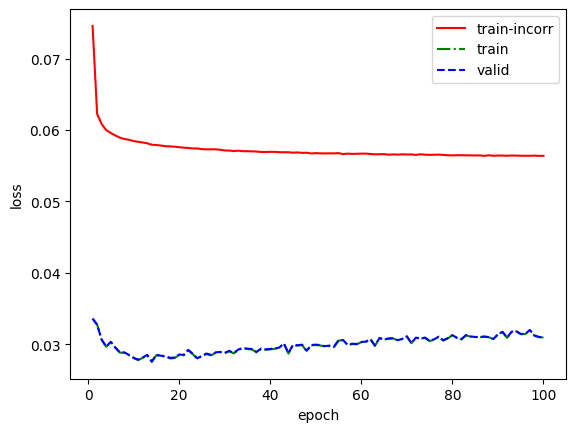

In [ ]:
# 5.10)
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss_incorrecta)+1),list_train_avg_loss_incorrecta,label="train-incorr",linestyle='-',c='red')
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

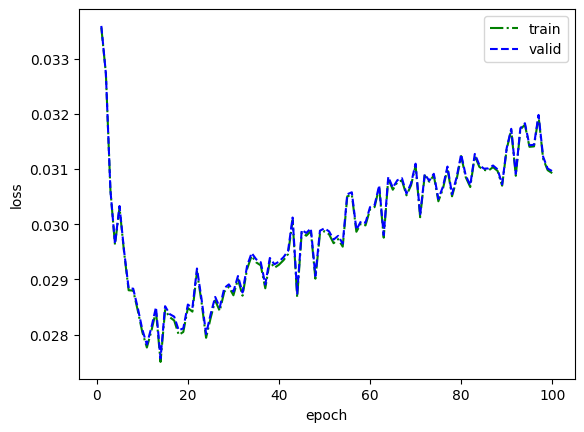

In [ ]:
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

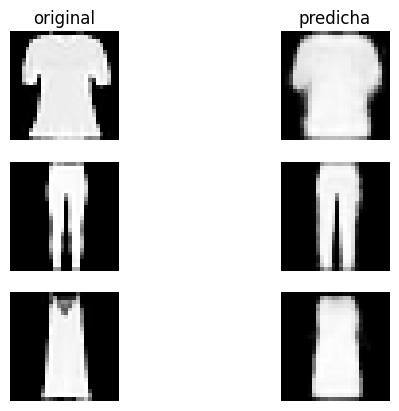

In [ ]:
# Miramos que imagenes predice el modelo sin entrenar
figure = plt.figure()
rows,cols = 3,2
i = 0 # subplot index
for row in range(1,rows+1):
    j = torch.randint(len(train_set_orig),size=(1,)).item() # elegimos un elemento random de el conjunto de entrenamiento
    # Ploteamos la imagen original
    i += 1
    image,flatten_imagen = train_set_orig[j]
    figure.add_subplot(rows,cols,i)
    if row==1: # le ponemos titulo solo a la primera imagen
      plt.title("original")
    plt.axis("off")
    plt.imshow(unbatch(image),cmap="Greys_r") # plotemaos la original
    # Ploteamos la imagen predicha
    i += 1
    figure.add_subplot(rows,cols,i)
    if row==1:
      plt.title("predicha")
    plt.axis("off")
    image_pred = unbatch(model(batch(image)))
    plt.imshow(image_pred,cmap="Greys_r")
plt.show()